In [1]:
import cv2
import tensorflow
import os
import numpy as np
from google.colab.patches import cv2_imshow
from tqdm import tqdm
import matplotlib.pyplot as plt
import random

In [2]:
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [3]:
os.environ['KAGGLE_USERNAME'] = 'gabevr'
os.environ['KAGGLE_KEY'] = 'ca479e66ac6ae221b62be68f056aca65'

In [4]:
!kaggle competitions download -c data-science-bowl-2018

100% 358M/358M [00:04<00:00, 80.4MB/s]



In [5]:
!unzip data-science-bowl-2018.zip

Archive:  data-science-bowl-2018.zip
  inflating: stage1_sample_submission.csv.zip  
  inflating: stage1_solution.csv.zip  
  inflating: stage1_test.zip         
  inflating: stage1_train.zip        
  inflating: stage1_train_labels.csv.zip  
  inflating: stage2_sample_submission_final.csv.zip  
  inflating: stage2_test_final.zip   


In [6]:
!unzip stage1_train.zip -d /content/treinamento/
!unzip stage1_test.zip -d /content/teste/

A saída de streaming foi truncada nas últimas 5000 linhas.
  inflating: /content/treinamento/d52958107d0b1f0288f50f346a833df3df485b92d5516cfcb536e73ab7adafd0/masks/d86ee01921b1c9ed23c342952253682060512483c39c8b7b5c6d8350f6df2568.png  
  inflating: /content/treinamento/d52958107d0b1f0288f50f346a833df3df485b92d5516cfcb536e73ab7adafd0/masks/d8b76279ad8f2e101bb8c5ca95229b6532903eea035ef945dd4a21356d49dead.png  
  inflating: /content/treinamento/d52958107d0b1f0288f50f346a833df3df485b92d5516cfcb536e73ab7adafd0/masks/dc05f946c096c5fcc147024843f21c06c3a94af25d4f37b498ea937953b806fe.png  
  inflating: /content/treinamento/d52958107d0b1f0288f50f346a833df3df485b92d5516cfcb536e73ab7adafd0/masks/e0fd1c4e98bb470bea315e7d8f74396450fe93e93f68e1f8a3443b2b397c8640.png  
  inflating: /content/treinamento/d52958107d0b1f0288f50f346a833df3df485b92d5516cfcb536e73ab7adafd0/masks/e4b6643cafde8ac789b63f7b1a023773960dbe63489963985033619fde052dc9.png  
  inflating: /content/treinamento/d52958107d0b1f0288f50f346a8

In [7]:
img_largura = 256
img_altura = 256
img_canais = 3
# define o tamanho das imagens e canais(3 pois é RGB)

In [8]:
seed = 42
# seed para reproduzir o resultado
np.random.seed = seed
random.seed = seed
path_treinamento = 'treinamento/'
#define os diretorios de treino e teste
path_teste = 'teste/'

In [9]:
train_ids = next(os.walk(path_treinamento))[1]
# pega todos os nomes dos arquivos de treino
test_ids = next(os.walk(path_teste))[1]
# pega os nomes de testes

In [10]:
len(train_ids), len(test_ids)
# quantidade dos dados de treino e teste

(670, 65)

In [11]:
dataset_img = np.zeros((len(train_ids), img_altura,img_largura, img_canais), dtype=np.uint8)
# cria umma matriz de quatro dimensoes preenchida com 0s, onde possui a quantidade de dados de treino, a altura e largura da imagem, e numero d e canais(3)
dataset_mask = np.zeros((len(train_ids), img_altura, img_largura,1),dtype=np.bool)
# mesma matriz mas agora para a mascara, que será o objeto segmentado da imagem, recebe somente 1 canal pois ele será apenas um contraste(uma mancha) que representa o objeto

In [12]:
dataset_img.shape, dataset_mask.shape
# qtd imagens | altura | largura | canais

((670, 256, 256, 3), (670, 256, 256, 1))

In [13]:
for n, id_, in tqdm(enumerate(train_ids), total=len(train_ids)):
  # loop que percorre todos os arquivos do loop
  path = path_treinamento + id_
  if '.' in path:
    continue

  img = cv2.imread(path + '/images/'+ id_+ '.png')[:,:,:img_canais]# pega e le a imagem que esta na pasta images com o id e .png
  img = cv2.resize(img, (img_altura, img_largura)) #redimensionando a imagem
  dataset_img[n] = img
  mask = np.zeros((img_altura, img_largura, 1), dtype=np.bool)# cria a mascara vazia para para depois concatenar todas as mascaras

  for mask_file in next(os.walk(path + '/masks/'))[2]:
  # loop que vai percorrer todas as mascaras
    mask_ = cv2.imread(path + '/masks/'+mask_file)
    # pega a mascara que esta na pasta
    mask_ = cv2.cvtColor(mask_, cv2.COLOR_BGR2GRAY)
    # transforma a mascara em escala de cinza
    mask_ = np.expand_dims(cv2.resize(mask_, (img_altura, img_largura)), axis = -1)
    # garantindo que a mascara esteja nas dimensoes certas(especificadas la em cima)
    mask = np.maximum(mask, mask_)# esta atribuido somente o os pixels segmentados
  dataset_mask[n] = mask
  # para cada 0 no dataset de mascaras, é atribuido somente os pixels segmentados

100%|██████████| 670/670 [00:41<00:00, 15.96it/s]


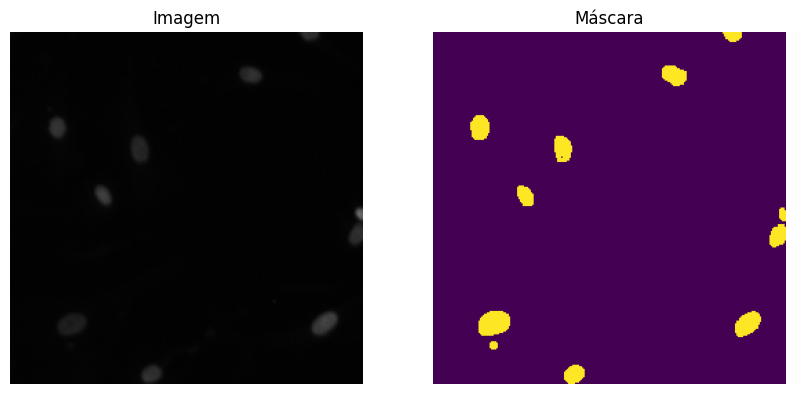

In [14]:
id_img = 6
fig = plt.figure(figsize=(10,7))

fig.add_subplot(1,2,1)
plt.imshow(dataset_img[id_img])
plt.axis('off')
plt.title('Imagem')

fig.add_subplot(1,2,2)
plt.imshow(np.squeeze(dataset_mask[id_img]))
plt.axis('off')
plt.title('Máscara');

In [15]:
x_test = np.zeros((len(test_ids), img_altura, img_largura, img_canais), dtype=np.uint8)
# base de teste com as dimensoes
redim_test = []
for n, id_ in tqdm(enumerate(test_ids), total=len(test_ids)):
  # segue o mesmo tipo do treino, mas agora as imagens de teste nao possuem mascara
    if "." in path:
        continue

    path = path_teste + id_
    img = cv2.imread(path + '/images/' + id_ + '.png')[:,:,:img_canais]
    redim_test.append([img.shape[0], img.shape[1]])
    img = cv2.resize(img, (img_altura, img_largura))
    x_test[n] = img

print('Ok!')
print(x_test.shape)

100%|██████████| 65/65 [00:00<00:00, 211.82it/s]

Ok!
(65, 256, 256, 3)


In [16]:
from sklearn.model_selection import train_test_split
x_train,x_val, y_train, y_val = train_test_split(dataset_img,dataset_mask,test_size=0.1)
#separação dos dados, x é a imagens originais e y é as mascaras

In [17]:
x_train.shape

(603, 256, 256, 3)

In [18]:
y_val.shape

(67, 256, 256, 1)

In [19]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, Conv2DTranspose, BatchNormalization, Dropout, Lambda, ReLU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Activation, MaxPool2D, Concatenate
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, TensorBoard

In [20]:
def bloco_conv(input, num_filters):
  # a separação por função, como por exemplo no bloco convolucional, permite com muita mais facilidade criar uma rede

  x = Conv2D(num_filters,3, padding='same')(input)
  # um kernel 3x3 vai passar pela imagem pegando o valor mais alto em cada posição do kernel
  x = BatchNormalization()(x)
  # normalização dos dados
  x = Activation('relu')(x)
  # função de ativação que subistui valores negativos por 0

  x = Conv2D(num_filters,3, padding='same')(input)
  x = BatchNormalization()(x)
  x = Activation('relu')(x)

  return x

In [21]:
def bloco_encoder(input,num_filters):
  # o encoder diminui o espaço de numeros para pegar as caracteristicas essenciais da imagem
  x = bloco_conv(input,num_filters=num_filters)
  # bloco convolução
  p = MaxPool2D((2,2))(x)
  # max pool vai diminuir pela metade o feature map(mapa de caracteristica retornado pelo bloco de convolução)
  return x, p

In [22]:
def bloco_decoder(input, skip_features, num_filters):
  # o bloco decoder é que vai aumentar a dimensionalidade da imagem, assim gerando um apossivel segmentaçã a partir das caracteristicas aprendidas
  x = Conv2DTranspose(num_filters, (2,2), strides=2, padding='same')(input)
  # aumenta a dimensionalidade criando feature maps em um bloco 2x2
  x = Concatenate()([x, skip_features])
  # o concatenação serve para que o decoder tenha uma referencia de oonde estava cada pixel assim nao borrando e atribuido pixels aonde nao deve
  x = bloco_conv(x,num_filters=num_filters)
  # convolução
  return x

In [23]:
def modelo_unet(input_shape):
  # função que vai chamar os blocos e montar a arquitetura da rede
  inputs = Input(input_shape)

  s1,p1 = bloco_encoder(inputs, 64)
  # convolução com 64 feature maps, retorna a convolução e o pooling
  s2,p2 = bloco_encoder(p1,128)
  s3,p3 = bloco_encoder(p2,256)
  s4,p4 = bloco_encoder(p3,512)

  b1 = bloco_conv(p4, 1024)

  d1 = bloco_decoder(b1, s4,512)
  # para cada decoder pega-se os mapas de caracteristicas(convoluções) correspondentes a layer, assim o decoder sabe como organizar os pixels segmentados em seu lugar em relação a imagem original
  d2 = bloco_decoder(d1, s3, 256)
  d3 = bloco_decoder(d2, s2, 128)
  d4 = bloco_decoder(d3, s1, 64)

  outputs = Conv2D(1,1, padding='same', activation='sigmoid')(d4)
  # retorna uma saida binária, sigmoid retorna um valor entre 0-1(prob)

  model = Model(inputs, outputs, name='U-Net')
  # instanciando o modelo com os inputs e outputs
  return model

In [24]:
model = modelo_unet((img_altura, img_largura, img_canais))
# criammos o modelo
model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])
# compilamos com o otimizador e funcao de erro e accuracy
model.summary()

Model: "U-Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │      1,024 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_5        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ activation_5[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │  1,180,160 │ max_pooling2d_2[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │      2,048 │ conv2d_7[0][0]    │
│ (BatchNormalizatio… │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_7        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 16, 16,    │          0 │ activation_7[0][

 Total params: 15,336,513 (58.50 MB)

 Trainable params: 15,330,625 (58.48 MB)

 Non-trainable params: 5,888 (23.00 KB)

In [25]:
# salvando os parametros dos modelos para posteriormente carregar
arquivo_modelo = 'modelo_unet.json'
modelo_json = model.to_json()
with open(arquivo_modelo, 'w') as json_file:
  json_file.write(modelo_json)

In [26]:
nome_modelo = 'modelo_unet.h5'
checkpointer = ModelCheckpoint(nome_modelo, verbose=1, save_best_only=True)
# salva o modelo em um checkpoint, para salvar o melhor modelo
early_stopper = EarlyStopping(patience = 5, monitor='val_loss')
# oara o treino da rede ao passar 5 apocas e nao ter melhora no val_loss
callbacks = [checkpointer, early_stopper]
#

In [27]:
epochs = 15
batch_size = 8

In [28]:
history = model.fit(x_train,y_train, batch_size=batch_size, epochs = epochs, validation_data=(x_val, y_val), callbacks=[callbacks])

Epoch 1/15
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 758ms/step - accuracy: 0.7257 - loss: 0.6382
Epoch 1: val_loss improved from None to 0.50362, saving model to modelo_unet.h5



Epoch 1: finished saving model to modelo_unet.h5
76/76 ━━━━━━━━━━━━━━━━━━━━ 128s 811ms/step - accuracy: 0.8417 - loss: 0.4818 - val_accuracy: 0.8790 - val_loss: 0.5036
Epoch 2/15
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step - accuracy: 0.9563 - loss: 0.2474
Epoch 2: val_loss improved from 0.50362 to 0.30467, saving model to modelo_unet.h5



Epoch 2: finished saving model to modelo_unet.h5
76/76 ━━━━━━━━━━━━━━━━━━━━ 23s 297ms/step - accuracy: 0.9599 - loss: 0.2321 - val_accuracy: 0.9330 - val_loss: 0.3047
Epoch 3/15
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step - accuracy: 0.9593 - loss: 0.2035
Epoch 3: val_loss improved from 0.30467 to 0.23330, saving model to modelo_unet.h5



Epoch 3: finished saving model to modelo_unet.h5
76/76 ━━━━━━━━━━━━━━━━━━━━ 23s 300ms/step - accuracy: 0.9605 - loss: 0.1969 - val_accuracy: 0.9556 - val_loss: 0.2333
Epoch 4/15
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step - accuracy: 0.9651 - loss: 0.1721
Epoch 4: val_loss improved from 0.23330 to 0.17535, saving model to modelo_unet.h5



Epoch 4: finished saving model to modelo_unet.h5
76/76 ━━━━━━━━━━━━━━━━━━━━ 23s 302ms/step - accuracy: 0.9674 - loss: 0.1617 - val_accuracy: 0.9660 - val_loss: 0.1753
Epoch 5/15
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - accuracy: 0.9690 - loss: 0.1491
Epoch 5: val_loss improved from 0.17535 to 0.15179, saving model to modelo_unet.h5


...


Epoch 10: finished saving model to modelo_unet.h5
76/76 ━━━━━━━━━━━━━━━━━━━━ 24s 314ms/step - accuracy: 0.9713 - loss: 0.1085 - val_accuracy: 0.9738 - val_loss: 0.1040
Epoch 11/15
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - accuracy: 0.9682 - loss: 0.1117
Epoch 11: val_loss did not improve from 0.10403
76/76 ━━━━━━━━━━━━━━━━━━━━ 24s 310ms/step - accuracy: 0.9715 - loss: 0.1041 - val_accuracy: 0.9690 - val_loss: 0.1150
Epoch 12/15
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - accuracy: 0.9717 - loss: 0.1045
Epoch 12: val_loss improved from 0.10403 to 0.08645, saving model to modelo_unet.h5



Epoch 12: finished saving model to modelo_unet.h5
76/76 ━━━━━━━━━━━━━━━━━━━━ 24s 319ms/step - accuracy: 0.9717 - loss: 0.1013 - val_accuracy: 0.9752 - val_loss: 0.0865
Epoch 13/15
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step - accuracy: 0.9722 - loss: 0.0978
Epoch 13: val_loss improved from 0.08645 to 0.08595, saving model to modelo_unet.h5



Epoch 13: finished saving model to modelo_unet.h5
76/76 ━━━━━━━━━━━━━━━━━━━━ 40s 309ms/step - accuracy: 0.9724 - loss: 0.0960 - val_accuracy: 0.9751 - val_loss: 0.0860
Epoch 14/15
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step - accuracy: 0.9735 - loss: 0.0938
Epoch 14: val_loss improved from 0.08595 to 0.07885, saving model to modelo_unet.h5



Epoch 14: finished saving model to modelo_unet.h5
76/76 ━━━━━━━━━━━━━━━━━━━━ 24s 312ms/step - accuracy: 0.9732 - loss: 0.0919 - val_accuracy: 0.9755 - val_loss: 0.0788
Epoch 15/15
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - accuracy: 0.9727 - loss: 0.0911
Epoch 15: val_loss improved from 0.07885 to 0.07723, saving model to modelo_unet.h5



Epoch 15: finished saving model to modelo_unet.h5
76/76 ━━━━━━━━━━━━━━━━━━━━ 24s 320ms/step - accuracy: 0.9726 - loss: 0.0908 - val_accuracy: 0.9768 - val_loss: 0.0772


In [29]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [30]:
def mostrar_graficos(history):
  # graficos de accuracy e val_accuracy
  # e grafico de loss e val loss
  fig = plt.gcf()
  fig.set_size_inches(16,4)
  plt.subplot(1,2,1)
  plt.plot(history.history['accuracy'], 'red', label='Accuracy treinamento')
  plt.plot(history.history['val_accuracy'], 'blue', label='Accuracy validação')
  plt.legend()
  plt.title('Accuracy')

  plt.subplot(1,2,2)
  plt.plot(history.history['loss'], 'red', label='Loss treinamento')
  plt.plot(history.history['val_loss'], 'blue', label='Loss validação')
  plt.legend()
  plt.title('Loss')
  plt.show()

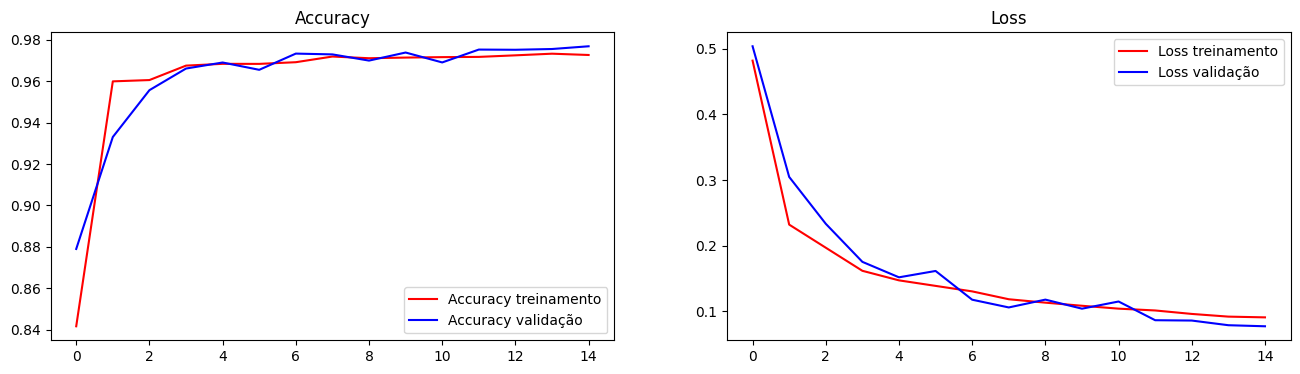

In [31]:
mostrar_graficos(history)

In [32]:
len(x_val)

67

In [33]:
predicoes_val = model.predict(x_val)
# previsões com o modelo na base de validação

3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 716ms/step


In [34]:
predicoes_val.shape

(67, 256, 256, 1)

In [35]:
predicoes_val[0].min(),predicoes_val[0].max()
# valores minimos e maximos representam a probabilidade da classe para aquele pixel

(np.float32(0.006101106), np.float32(1.0))

In [36]:
predicoes_val = (predicoes_val > 0.5).astype(np.int8)
# converte o que for maior 0.5 para 1 e menor 0
predicoes_val

array([[[[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        [[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        [[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        ...,

        [[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        [[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        [[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]]],


       [[[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        [[0],
         [1],
         [0],
         ...,
         [0],
         [0],
         [0]],

        [[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        ...,

        [[0],
         [0],
         [0],
         ...,
         [0],


In [37]:
np.unique(predicoes_val[0], return_counts=True)
# quantos valores unicos tem na imagem prevista

(array([0, 1], dtype=int8), array([63730,  1806]))

In [38]:
def compara_segmentacoes(original, ground_truth, predicao):
  # comparando lado a lado a imagem original, a mascara correta e a predição do modelo
  fig = plt.figure(figsize=(12, 7))

  fig.add_subplot(1,3,1)
  plt.imshow(original)
  plt.axis("off")
  plt.title("Imagem Original")

  fig.add_subplot(1,3,2)
  plt.imshow(ground_truth)
  plt.axis("off")
  plt.title("Máscara real (ground truth)")

  fig.add_subplot(1,3,3)
  plt.imshow(predicao)
  plt.axis("off")
  plt.title("Predição")

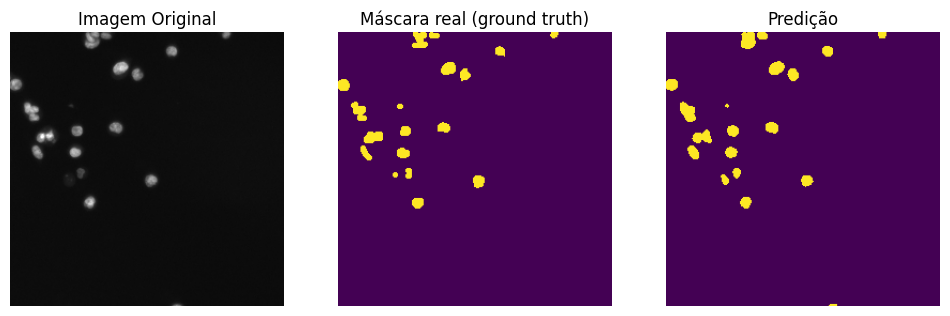

In [39]:
idx = 0
compara_segmentacoes(x_val[idx], np.squeeze(y_val[idx]), np.squeeze(predicoes_val[idx]))
# chamando a função

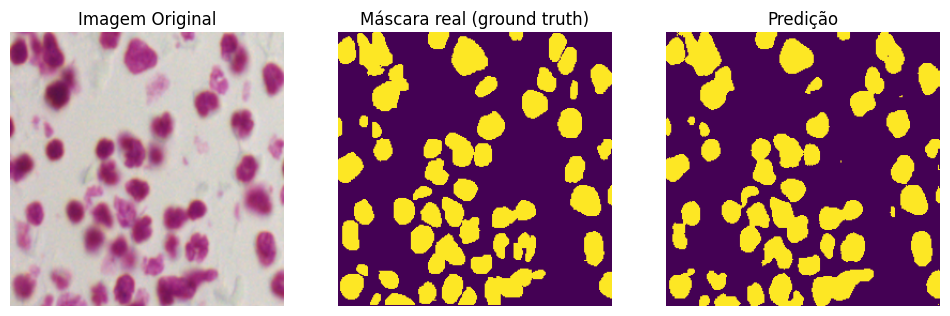

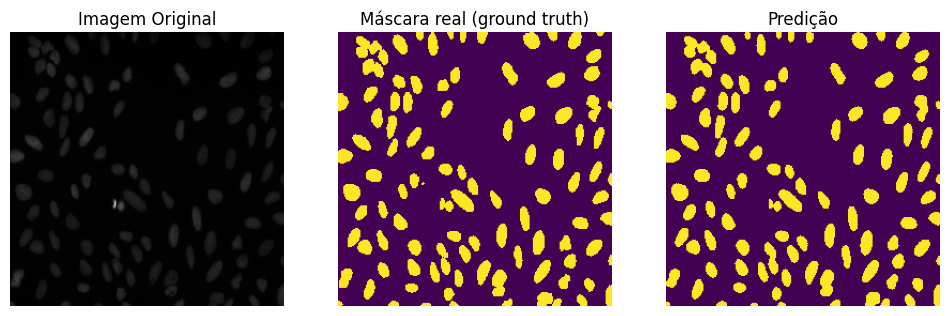

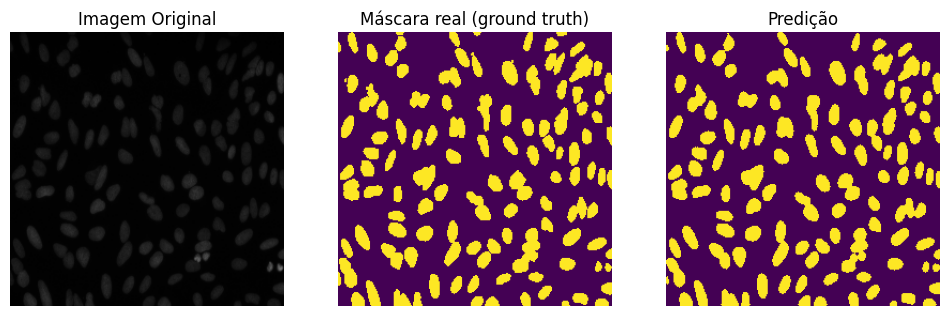

In [40]:
imgs_teste = np.random.choice(len(x_val), 3)
for img_id in imgs_teste:
  compara_segmentacoes(x_val[img_id], np.squeeze(y_val[img_id]), np.squeeze(predicoes_val[img_id]))

In [41]:
predicoes_teste = model.predict(x_test)
# prevendo para a base de teste
predicoes_teste = (predicoes_teste > 0.5).astype(np.uint8)

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step


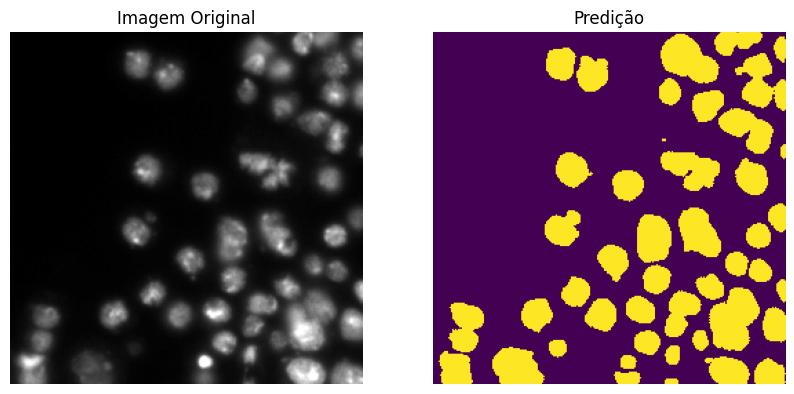

In [42]:
idx = random.randint(0, len(x_test))

fig = plt.figure(figsize=(10, 7))

fig.add_subplot(1,2,1)
plt.imshow(x_test[idx])
plt.axis("off")
plt.title("Imagem Original")

fig.add_subplot(1,2,2)
plt.imshow(np.squeeze(predicoes_teste[idx]))
plt.axis("off")
plt.title("Predição");

Text(0.5, 1.0, 'Máscara real')

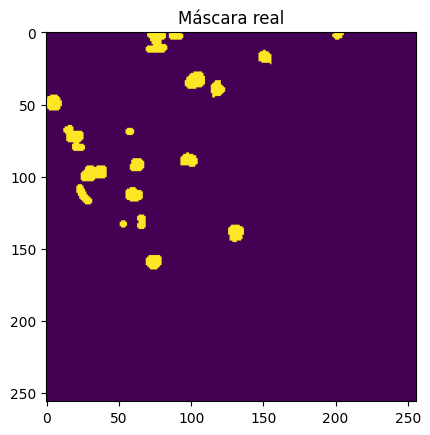

In [44]:
id_img_teste = 0
# imagem prevista no treino
img_teste = x_val[id_img_teste]
ground_truth = y_val[id_img_teste]
plt.imshow(np.squeeze(ground_truth))
plt.title('Máscara real')

In [45]:
from tensorflow.keras.metrics import MeanIoU
iou_resultado = MeanIoU(num_classes = 2)
# instanciando a funcao de calculo para 2 classes

In [46]:
test_img_input = np.expand_dims(img_teste, 0)
# adiciona uma dimensao
test_img_input.shape

(1, 256, 256, 3)

In [47]:
predicao = (model.predict(test_img_input)[0,:,:,0] > 0.5).astype(np.uint8)
# predição com uma imagem de teste

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step


IoU para a imagem:  0.88844544


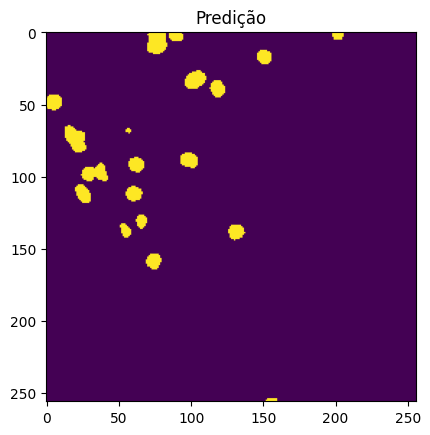

In [48]:
plt.imshow(predicao)
plt.title('Predição')
iou_resultado.update_state(ground_truth[:,:,0], predicao)
# calculando o IoU para a a previsao comoarando com a imagem real
print('IoU para a imagem: ', iou_resultado.result().numpy())

In [50]:
y_val[0]

array([[[False],
        [False],
        [False],
        ...,
        [False],
        [False],
        [False]],

       [[False],
        [False],
        [False],
        ...,
        [False],
        [False],
        [False]],

       [[False],
        [False],
        [False],
        ...,
        [False],
        [False],
        [False]],

       ...,

       [[False],
        [False],
        [False],
        ...,
        [False],
        [False],
        [False]],

       [[False],
        [False],
        [False],
        ...,
        [False],
        [False],
        [False]],

       [[False],
        [False],
        [False],
        ...,
        [False],
        [False],
        [False]]])

In [51]:
import pandas as pd

valores_IoU = []
# loop para calcular o IoU para as prredições do modelo as imagens de val
for idx in range(0, x_val.shape[0]):
  # para cada imagem dentro de x_val
    img = x_val[idx]
    ground_truth = y_val[idx]
  # pega a resposta real para as iamgens de val
    IoU = MeanIoU(num_classes=2)

    test_img_input=np.expand_dims(img, 0)
    predicao = (model.predict(test_img_input)[0,:,:,0] > 0.5).astype(np.uint8)
    # para a predicao do modelo coloca 1 para mais que 50% de previsao para o pixel
    IoU.update_state(ground_truth[:,:,0], predicao)
    # calculando a metrica para a imagem idx
    IoU_resultado = IoU.result().numpy()
    # resultado convertido para numero numpy
    valores_IoU.append(IoU_resultado)
    # adiciona a lista
    print(IoU_resultado)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
0.88844544
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
0.85757834
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
0.9431342
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
0.83577013
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
0.95432913
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
0.8656217
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
0.9139072
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
0.86165154
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
0.9111342
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
0.96203965
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
0.95773304
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
0.6449079
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
0.84638023
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
0.8272428
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
0.88929915
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
0.934273
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
0.9688771
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
0.9354886
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
0.9572889
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
0.9664433
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms

In [52]:
df = pd.DataFrame(valores_IoU, columns=["IoU"])
# colocando em um dataframe os valores de Iou para cada imagem
df = df[df.IoU != 1.0]
# para cada resultado diferente 1 atribui ao dataframe
df

,IoU
0,0.888445
1,0.857578
2,0.943134
3,0.835770
4,0.954329
...,...
62,0.965985
63,0.967675
64,0.908816
65,0.940034


In [53]:
media_IoU = df.mean().values
# media dos valores de IoU
print("Média do IoU para "+str(len(valores_IoU))+" imagens: ", media_IoU)

Média do IoU para 67 imagens:  [0.900851]


In [54]:
from tensorflow.keras.models import model_from_json

json_file = open('/content/modelo_unet.json', 'r')
# carregando a rede salva
loaded_model_json = json_file.read()
json_file.close()
modelo2 = model_from_json(loaded_model_json)

In [55]:
modelo2.load_weights('/content/modelo_unet.h5')
# carregando os pesos do modelo salvo

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


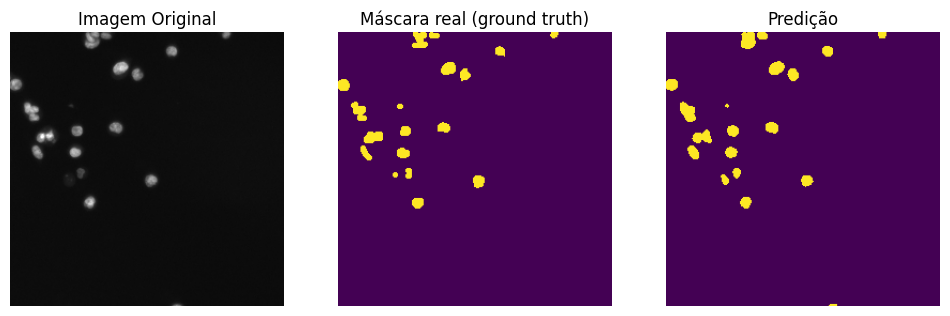

In [56]:
idx = 0
#testando o modelo carregado

img_teste = np.expand_dims(x_val[idx], 0)
predicao_val = modelo2.predict(img_teste, verbose=1)
predicao_val = (predicao_val > 0.5).astype(np.uint8)

compara_segmentacoes(x_val[idx], np.squeeze(y_val[idx]), np.squeeze(predicao_val[idx]))